# Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift

Replication of Ioffe and Szegedy (2015), *Batch Normalization: Accelerating Deep Network
Training by Reducing Internal Covariate Shift*, ICML.

We train two identical deep fully connected networks on MNIST, one with a BatchNorm
layer after every hidden linear layer and one without, using the same (relatively high)
learning rate. The paper's key claim is that batch normalization lets us train deeper
networks faster and more stably; we reproduce the faster, smoother convergence.

In [1]:
import torch, torch.nn as nn
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [2]:
tf = T.Compose([T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
train = tv.datasets.MNIST("../data", train=True,  download=True, transform=tf)
test  = tv.datasets.MNIST("../data", train=False, download=True, transform=tf)
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
test_dl  = torch.utils.data.DataLoader(test,  batch_size=512)
print("train", len(train), "test", len(test))

train 60000 test 10000


In [3]:
# Deep 5-hidden-layer MLP. The 'bn' flag toggles a BatchNorm1d after each linear layer.
class DeepMLP(nn.Module):
    def __init__(self, bn):
        super().__init__()
        layers, d = [nn.Flatten()], 784
        for h in [256, 256, 256, 256, 256]:
            layers.append(nn.Linear(d, h))
            if bn: layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU()); d = h
        layers.append(nn.Linear(d, 10))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

In [4]:
def train_model(bn, epochs=5, lr=0.1):
    net = DeepMLP(bn)
    opt = torch.optim.SGD(net.parameters(), lr=lr)   # high LR stresses the no-BN net
    lf = nn.CrossEntropyLoss()
    step_loss, test_acc = [], []
    for ep in range(epochs):
        net.train()
        for x, y in train_dl:
            opt.zero_grad(); loss = lf(net(x), y); loss.backward(); opt.step()
            step_loss.append(loss.item())
        net.eval()
        with torch.no_grad():
            acc = sum((net(x).argmax(1) == y).sum().item() for x, y in test_dl) / len(test)
        test_acc.append(acc)
        print(f"  bn={bn} epoch {ep+1}: test_acc={acc:.4f}")
    return step_loss, test_acc

print("Without BatchNorm:"); nobn_loss, nobn_acc = train_model(False)
print("With BatchNorm:");    bn_loss,   bn_acc   = train_model(True)

Without BatchNorm:


  bn=False epoch 1: test_acc=0.9324


  bn=False epoch 2: test_acc=0.9569


  bn=False epoch 3: test_acc=0.9721


  bn=False epoch 4: test_acc=0.9690


...

  bn=True epoch 1: test_acc=0.9720


  bn=True epoch 2: test_acc=0.9751


  bn=True epoch 3: test_acc=0.9790


  bn=True epoch 4: test_acc=0.9795


  bn=True epoch 5: test_acc=0.9783


In [5]:
print(f"Final test accuracy  no-BN: {nobn_acc[-1]:.4f}   BN: {bn_acc[-1]:.4f}")
print(f"Loss after 100 steps no-BN: {sum(nobn_loss[:100])/100:.3f}   BN: {sum(bn_loss[:100])/100:.3f}")

Final test accuracy  no-BN: 0.9753   BN: 0.9783
Loss after 100 steps no-BN: 2.270   BN: 0.391


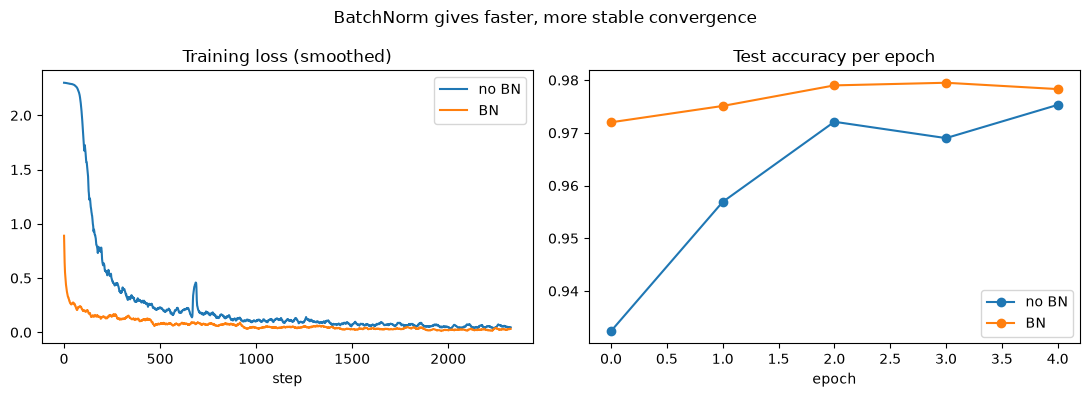

In [6]:
def smooth(v, k=20):
    import numpy as np
    return np.convolve(v, np.ones(k)/k, mode="valid")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(smooth(nobn_loss), label="no BN"); ax[0].plot(smooth(bn_loss), label="BN")
ax[0].set_title("Training loss (smoothed)"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(nobn_acc, marker="o", label="no BN"); ax[1].plot(bn_acc, marker="o", label="BN")
ax[1].set_title("Test accuracy per epoch"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("BatchNorm gives faster, more stable convergence"); plt.tight_layout(); plt.show()